In [1]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 8.4 MB/s eta 0:00:00


In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import mglearn
import pandas as pd

In [3]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

Building decision tree model using the default setting of fully developing the tree (growing the tree until all leaves are pure).

In [4]:
# Default Model
dtc = DecisionTreeClassifier(random_state=0) # random_state is set to make internal split decisions reproducible
dtc.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [5]:
print("Training set Score: {:.3f}".format(dtc.score(X_train, y_train)))
print("Testing set Score: {:.3f}".format(dtc.score(X_test, y_test)))

Training set Score: 1.000
Testing set Score: 0.937


The accuracy on the training set is 100%. because the leaves are pure, the tree was grown deep enough that it could perfectly memorize all the labels on the training data. The test set accuracy is slightly worse than for the linear models that tested on same dataset previously, which had around 95% accuracy.

There are two common strategies to prevent overfitting: stopping the creation of the tree early (also called pre-pruning), or building the tree but then removing or collapsing nodes that contain little information (also called post-pruning or just pruning). Possible criteria for pre-pruning include limiting the maximum depth of the tree, limiting the maximum number of leaves, or requiring a minimum number of points in a node to keep splitting it.

Below is a pruned tree, which will stop developing the tree before we perfectly fit to the training data. One option is to stop building the tree after a certain depth has been reached. below we set max_depth=4, meaning that the decision tree is allowed to grow only up to 4 levels deep (4 consecutive splits from the root). Limiting the depth of the tree decreases overfitting. This leads to a lower accuracy on the training set, but an improvement on the test set.

In [6]:
# Prepruned Model
dtc1 = DecisionTreeClassifier(random_state=0, max_depth=4)
dtc1.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=0)

In [7]:
print("Training set Score: {:.3f}".format(dtc1.score(X_train, y_train)))
print("Testing set Score: {:.3f}".format(dtc1.score(X_test, y_test)))

Training set Score: 0.988
Testing set Score: 0.951


# Analyzing Decision Trees

We can visualize the tree using the export_graphviz function from the tree module. This writes a file in the .dot file format, which is a text file format for storing graphs. We set an option to color the nodes to reflect the majority class in each node and pass the class and features names so the tree can be properly labeled

In [8]:
from sklearn.tree import export_graphviz
export_graphviz(dtc1, out_file="dtc1.dot", class_names=cancer.target_names,
                feature_names=cancer.feature_names, impurity=False, filled=True)

We can read this file and visualize it using the graphviz module as below (or you can use any program that can read .dot files)

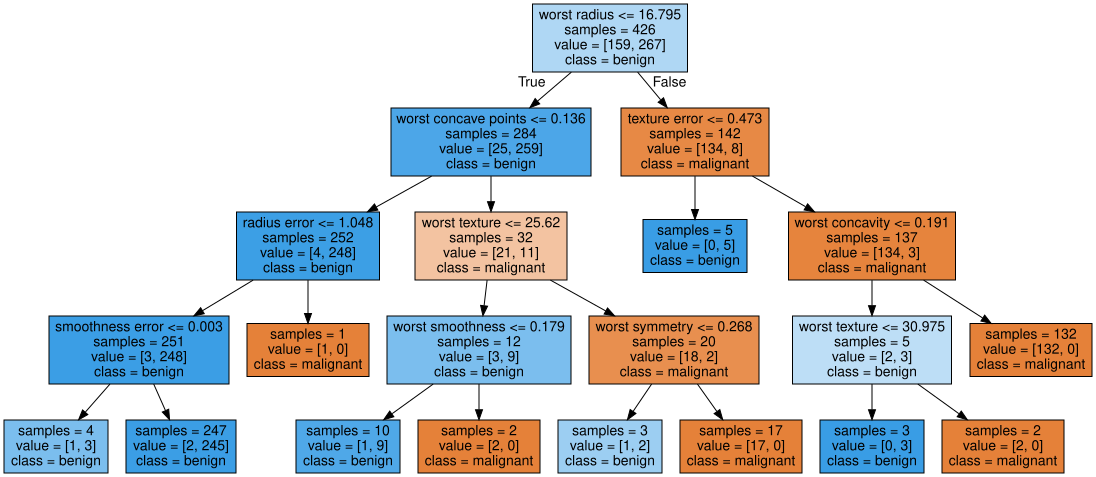

In [9]:
import graphviz

with open("dtc1.dot") as f:
  dot_graph = f.read()
display(graphviz.Source(dot_graph))

The visualization of the tree provides a great in-depth view of how the algorithm makes predictions.

The samples shown in each node in the figure gives the number of samples in that node, while value provides the number of samples per class. Following the branches to the right, we see that worst radius > 16.795 creates a node that contains only 8 benign but 134 malignant samples. The rest of this side of the tree then uses some finer distinctions to split off these 8 remaining benign samples. Of the 142 samples that went to the right in the initial split, nearly all of them (132) end up in the leaf to the very right.

Taking a left at the root, for worst radius <= 16.795 we end up with 25 malignant and 259 benign samples. Nearly all of the benign samples end up in the second leaf from the left, with most of the other leaves containing very few samples.

# Feature Importance in Trees

Instead of looking at the whole tree, there are some useful properties that we can derive to summarize the workings of the tree. The most commonly used summary is **feature importance**, which rates how important each feature is for the decision a tree makes. It is a number between 0 and 1 for each feature, where 0 means “not used at all” and 1 means “perfectly predicts the target.” The feature importances always sum to 1

In [10]:
print("Feature Importances: \n", dtc1.feature_importances_)

Feature Importances: 
 [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.01019737 0.04839825
 0.         0.         0.0024156  0.         0.         0.
 0.         0.         0.72682851 0.0458159  0.         0.
 0.0141577  0.         0.018188   0.1221132  0.01188548 0.        ]


  Below is a visualization of the feature importances.

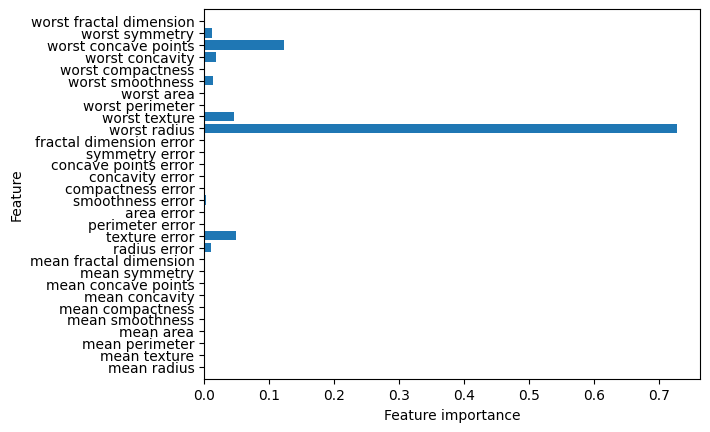

In [11]:
def plot_feature_importances_cancer(model):
  n_features = cancer.data.shape[1]
  plt.barh(np.arange(n_features), model.feature_importances_, align='center')
  plt.yticks(np.arange(n_features), cancer.feature_names)
  plt.xlabel("Feature importance")
  plt.ylabel("Feature")
  plt.ylim(-1, n_features)


plot_feature_importances_cancer(dtc1)

The feature used in the top split (“worst radius”) is by far the most important feature. This confirms the observation in analyzing the tree that the first level already separates the two classes fairly well.

However, if a feature has a low value in feature_importance_, it doesn’t mean that this feature is uninformative. It only means that the feature was not picked by the tree, likely because another feature encodes the same information.

In contrast to the coefficients in linear models, feature importances are always positive, and don’t encode which class a feature is indicative of. The feature importances tell us that “worst radius” is important, but not whether a high radius is indicative of a sample being benign or malignant.

Feature importances: [0. 1.]


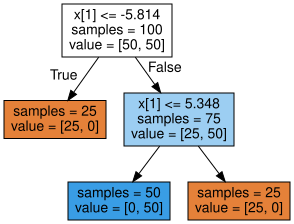

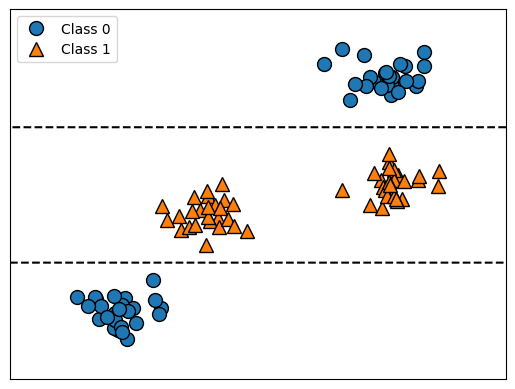

In [12]:
tree = mglearn.plots.plot_tree_not_monotone()
display(tree)

The above plot shows a dataset with two features and two classes. Here, all the information is contained in X[1], and X[0] is not used at all. But the relation between X[1] and the output class is not monotonous, meaning we cannot say “a high value of X[1] means class 0, and a low value means class 1” (or vice versa).

 The usage and analysis of regression trees is very similar to that of classification trees.

But DecisionTreeRegressor (and all other tree-based regression models) is not able to extrapolate, or make predictions outside of the range of the training data.

Below illustration visualizes it clearly using a dataset of historical computer memory (RAM) prices with the date on the x-axis and the price of one megabyte of RAM in that year on the y-axis.

Text(0, 0.5, 'Price in $/Mbyte')

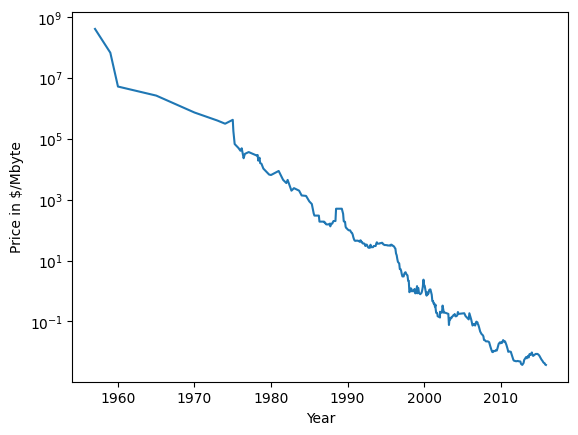

In [13]:
import os
ram_prices = pd.read_csv(os.path.join(mglearn.datasets.DATA_PATH, "ram_price.csv"))

plt.semilogy(ram_prices.date, ram_prices.price)
plt.xlabel("Year")
plt.ylabel("Price in $/Mbyte")

Below is a forecast made for the years after 2000 using the historical data up to that point, with the date as our only feature.

We will compare two simple models: a DecisionTreeRegressor and LinearRegression. We rescale the prices using a logarithm, so that the relationship is relatively linear. This doesn’t make a difference for the DecisionTreeRegressor, but it makes a big difference for LinearRegression.

After training the models and making predictions, we apply the exponential map to undo the logarithm transform. We make predictions on the whole dataset for visualization purposes here.

In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

# use historical data to forecast prices after the year 2000
data_train = ram_prices[ram_prices.date < 2000]
data_test = ram_prices[ram_prices.date >= 2000]

# predict prices based on date
X_train = data_train.date.values[:, np.newaxis]
# we use a log-transform to get a simpler relationship of data to target
y_train = np.log(data_train.price)

tree = DecisionTreeRegressor(max_depth=3).fit(X_train, y_train)
linear_reg = LinearRegression().fit(X_train, y_train)

# predict on all data
X_all = ram_prices.date.values[:, np.newaxis]

pred_tree = tree.predict(X_all)
pred_lr = linear_reg.predict(X_all)

# undo log-transform
price_tree = np.exp(pred_tree)
price_lr = np.exp(pred_lr)

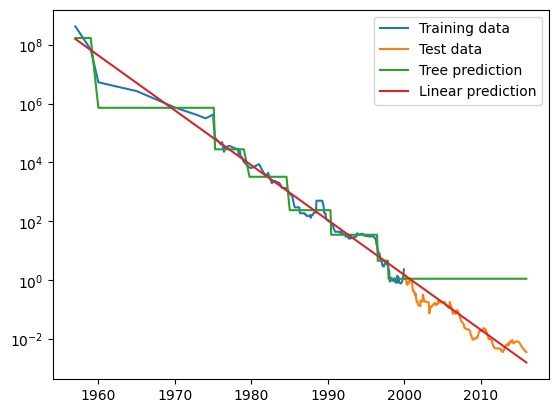

In [15]:
plt.semilogy(data_train.date, data_train.price, label="Training data")
plt.semilogy(data_test.date, data_test.price, label="Test data")
plt.semilogy(ram_prices.date, price_tree, label="Tree prediction")
plt.semilogy(ram_prices.date, price_lr, label="Linear prediction")
plt.legend()

The difference between the models is quite striking. The linear model approximates the data with a line, as we knew it would. This line provides quite a good forecast for the test data (the years after 2000), while glossing over some of the finer variations in both the training and the test data. The tree model, on the other hand, makes perfect predictions on the training data; we did not restrict the complexity of the tree, so it learned the whole dataset by heart. However, once we leave the data range for which the model has data, the model simply keeps predicting the last known point. The tree has no ability to generate “new” responses, outside of what was seen in the training data. This shortcoming applies to all models based on trees.